<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

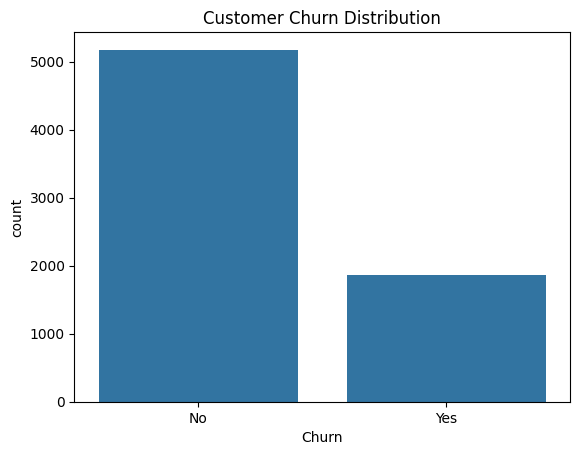

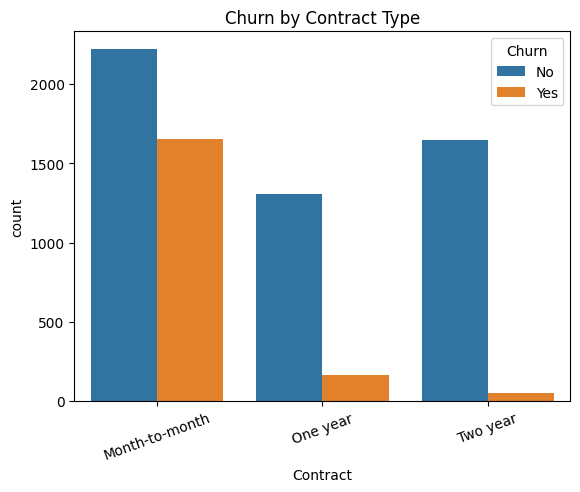

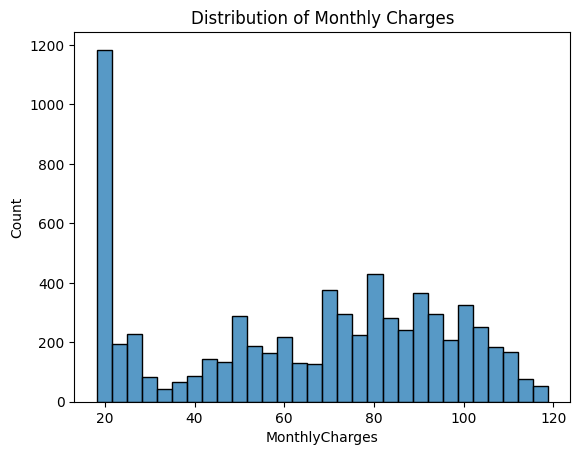

Accuracy: 0.7934705464868701

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.65      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



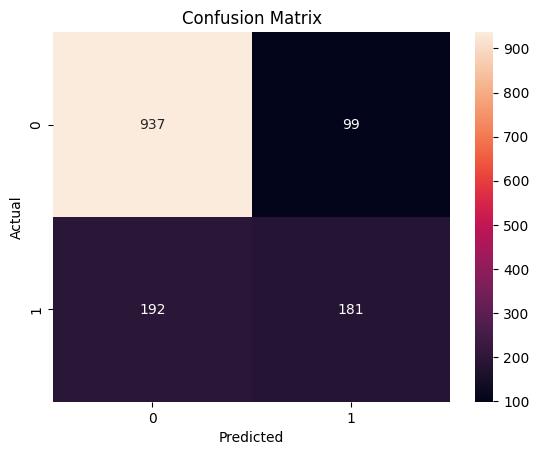

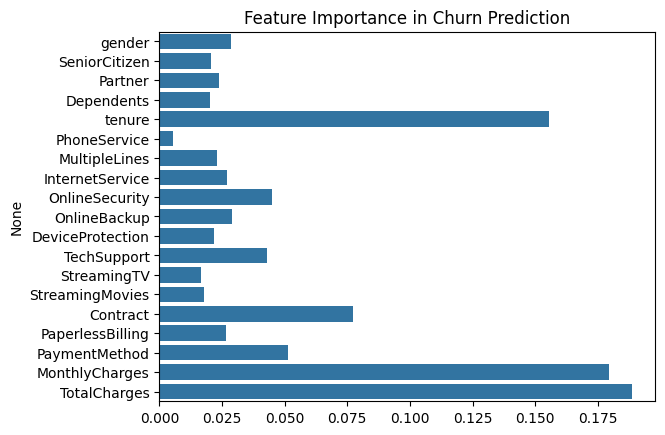

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("ba.csv")

# Drop customerID
data = data.drop("customerID", axis=1)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

# Fill missing values
data = data.fillna(0)

# Visualization 1: Churn Distribution
plt.figure()
sns.countplot(x="Churn", data=data)
plt.title("Customer Churn Distribution")
plt.show()

# Visualization 2: Contract vs Churn
plt.figure()
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

# Visualization 3: Monthly Charges Distribution
plt.figure()
sns.histplot(data["MonthlyCharges"], bins=30)
plt.title("Distribution of Monthly Charges")
plt.show()

# Encode categorical variables
le = LabelEncoder()
for column in data.columns:
    if data[column].dtype == object:
        data[column] = le.fit_transform(data[column])

# Split input and output
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualization 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Visualization 5: Feature Importance
importance = model.feature_importances_
features = X.columns

plt.figure()
sns.barplot(x=importance, y=features)
plt.title("Feature Importance in Churn Prediction")
plt.show()